In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns

In [3]:
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [4]:
X_list = cars.wt.values
X_np = np.array(X_list,dtype = np.float32).reshape(-1,1)
X = torch.from_numpy(X_np)

In [5]:
X_list

array([2.62 , 2.875, 2.32 , 3.215, 3.44 , 3.46 , 3.57 , 3.19 , 3.15 ,
       3.44 , 3.44 , 4.07 , 3.73 , 3.78 , 5.25 , 5.424, 5.345, 2.2  ,
       1.615, 1.835, 2.465, 3.52 , 3.435, 3.84 , 3.845, 1.935, 2.14 ,
       1.513, 3.17 , 2.77 , 3.57 , 2.78 ])

In [6]:
X_np

array([[2.62 ],
       [2.875],
       [2.32 ],
       [3.215],
       [3.44 ],
       [3.46 ],
       [3.57 ],
       [3.19 ],
       [3.15 ],
       [3.44 ],
       [3.44 ],
       [4.07 ],
       [3.73 ],
       [3.78 ],
       [5.25 ],
       [5.424],
       [5.345],
       [2.2  ],
       [1.615],
       [1.835],
       [2.465],
       [3.52 ],
       [3.435],
       [3.84 ],
       [3.845],
       [1.935],
       [2.14 ],
       [1.513],
       [3.17 ],
       [2.77 ],
       [3.57 ],
       [2.78 ]], dtype=float32)

In [7]:
X

tensor([[2.6200],
        [2.8750],
        [2.3200],
        [3.2150],
        [3.4400],
        [3.4600],
        [3.5700],
        [3.1900],
        [3.1500],
        [3.4400],
        [3.4400],
        [4.0700],
        [3.7300],
        [3.7800],
        [5.2500],
        [5.4240],
        [5.3450],
        [2.2000],
        [1.6150],
        [1.8350],
        [2.4650],
        [3.5200],
        [3.4350],
        [3.8400],
        [3.8450],
        [1.9350],
        [2.1400],
        [1.5130],
        [3.1700],
        [2.7700],
        [3.5700],
        [2.7800]])

In [8]:
y_list = cars.mpg.values
y_np = np.array(y_list,dtype = np.float32).reshape(-1,1)
y_true = torch.from_numpy(y_np)
y_true

tensor([[21.0000],
        [21.0000],
        [22.8000],
        [21.4000],
        [18.7000],
        [18.1000],
        [14.3000],
        [24.4000],
        [22.8000],
        [19.2000],
        [17.8000],
        [16.4000],
        [17.3000],
        [15.2000],
        [10.4000],
        [10.4000],
        [14.7000],
        [32.4000],
        [30.4000],
        [33.9000],
        [21.5000],
        [15.5000],
        [15.2000],
        [13.3000],
        [19.2000],
        [27.3000],
        [26.0000],
        [30.4000],
        [15.8000],
        [19.7000],
        [15.0000],
        [21.4000]])

# **model(class)**

In [9]:
class LinearRegressionTorch(nn.Module):
    def __init__(self,input_size,output_size):
        super(LinearRegressionTorch,self).__init__()
        self.linear = nn.Linear(input_size,output_size)
    def forward (self,X):
        out = self.linear(X)
        return out
input_dim = 1
output_dim = 1
model = LinearRegressionTorch(input_dim,output_dim)
    

# LOSS FUNCTION

In [10]:
loss_func = nn.MSELoss()

# OPTIMIZER

In [11]:
LR= 0.01
optimizer = torch.optim.SGD(model.parameters(),lr = LR)

# TRAINING

In [12]:
losses,slope,bias = [],[],[]
BATCH_SIZE = 2
num_epochs = 1000
for i in range (num_epochs):
    for i in range (0,X.shape[0],BATCH_SIZE):
        # set gradients to Zero
        optimizer.zero_grad()
    
        # forward pass
        y_pred = model(X[i:i+BATCH_SIZE])  # for Example i=0:i=0 + BATCH_SIZE=2
    
        # compute loss
        loss = loss_func(y_pred,y_true[i:i+BATCH_SIZE])
        loss.backward()
    
        # update weight
        optimizer.step()
    
        # get parameters
        for name,param in model.named_parameters():
            if param.requires_grad:
                if name == 'linear.weight':
        # 1. param.data extracts the underlying tensor values without history
        # 2. .numpy() converts the PyTorch tensor into a standard NumPy array
    #3.[0][0] extracts the single scalar value out of the 2D array matrix [[value]]
                    slope.append(param.data.numpy()[0][0])
                # Check if the current parameter is the bias (y-intercept)
                if name == 'linear.bias':
                # 1. param.data.numpy() converts the tensor to a NumPy array
        # 2. [0] extracts the single scalar value out of the 1D array [value]
                    bias.append(param.data.numpy()[0])
    
    
        # store loss
        losses.append(float(loss.data))
    
        # vizualise the loss
        if i % 100 == 0:
            print("Epoch = {},loss:{:.4f}".format(i,loss.data))

Epoch = 0,loss:367.3720
Epoch = 0,loss:24.0620
Epoch = 0,loss:21.5779
Epoch = 0,loss:20.3682
Epoch = 0,loss:19.2309
Epoch = 0,loss:18.1526
Epoch = 0,loss:17.1304
Epoch = 0,loss:16.1613
Epoch = 0,loss:15.2430
Epoch = 0,loss:14.3727
Epoch = 0,loss:13.5482
Epoch = 0,loss:12.7672
Epoch = 0,loss:12.0276
Epoch = 0,loss:11.3272
Epoch = 0,loss:10.6641
Epoch = 0,loss:10.0365
Epoch = 0,loss:9.4426
Epoch = 0,loss:8.8807
Epoch = 0,loss:8.3493
Epoch = 0,loss:7.8467
Epoch = 0,loss:7.3716
Epoch = 0,loss:6.9225
Epoch = 0,loss:6.4982
Epoch = 0,loss:6.0974
Epoch = 0,loss:5.7189
Epoch = 0,loss:5.3616
Epoch = 0,loss:5.0244
Epoch = 0,loss:4.7062
Epoch = 0,loss:4.4062
Epoch = 0,loss:4.1234
Epoch = 0,loss:3.8568
Epoch = 0,loss:3.6057
Epoch = 0,loss:3.3693
Epoch = 0,loss:3.1468
Epoch = 0,loss:2.9375
Epoch = 0,loss:2.7407
Epoch = 0,loss:2.5558
Epoch = 0,loss:2.3820
Epoch = 0,loss:2.2190
Epoch = 0,loss:2.0660
Epoch = 0,loss:1.9226
Epoch = 0,loss:1.7882
Epoch = 0,loss:1.6624
Epoch = 0,loss:1.5447
Epoch = 0,loss:

<Axes: >

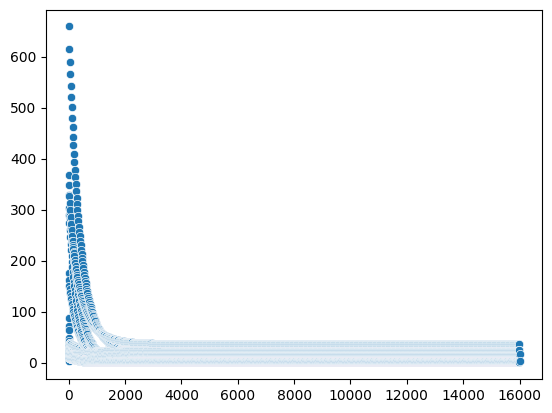

In [13]:
sns.scatterplot(x=range(len(losses)),y=losses)

<Axes: >

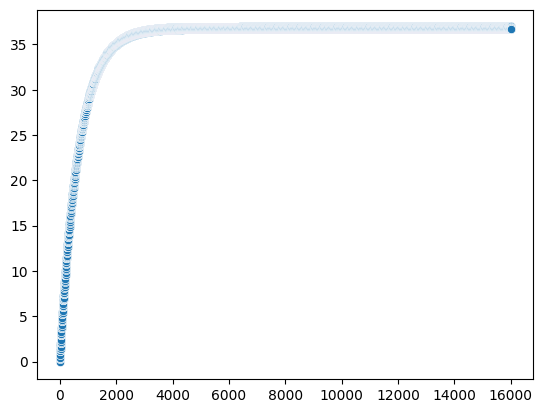

In [14]:
sns.scatterplot(x=range(len(bias)),y=bias)

<Axes: >

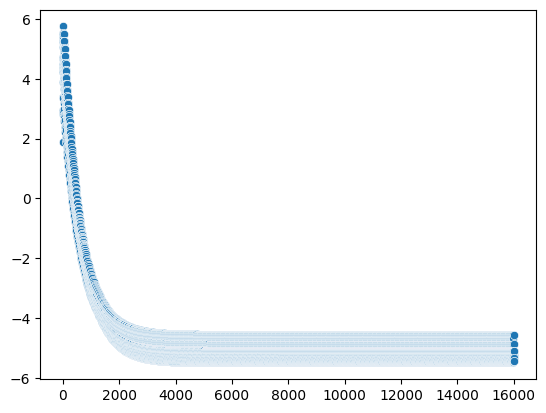

In [15]:
sns.scatterplot(x=range(len(slope)),y=slope)

<Axes: >

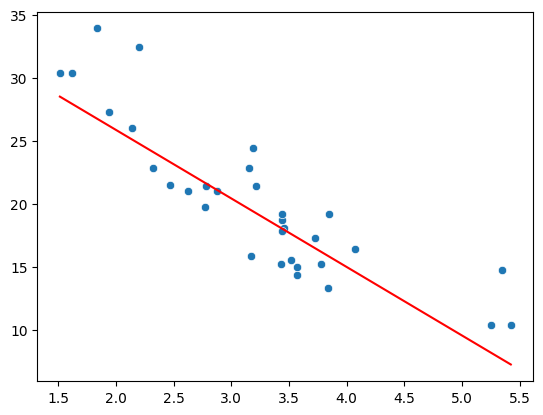

In [16]:
y_pred = model(X).data.numpy().reshape(-1)
sns.scatterplot(x=X_list , y=y_list)
sns.lineplot(x=X_list ,y=y_pred,color='red')